In [2]:
import pandas as pd

# Files load 
train = pd.read_csv('train-Copy1.csv')
features = pd.read_csv('features-Copy1.csv')
stores = pd.read_csv('stores.csv')

# Look data
print(train.head())

   Store  Dept        Date  Weekly_Sales  IsHoliday
0      1     1  2010-02-05      24924.50      False
1      1     1  2010-02-12      46039.49       True
2      1     1  2010-02-19      41595.55      False
3      1     1  2010-02-26      19403.54      False
4      1     1  2010-03-05      21827.90      False


In [3]:
print(features.head())

   Store        Date  Temperature  Fuel_Price  MarkDown1  MarkDown2  \
0      1  2010-02-05        42.31       2.572        NaN        NaN   
1      1  2010-02-12        38.51       2.548        NaN        NaN   
2      1  2010-02-19        39.93       2.514        NaN        NaN   
3      1  2010-02-26        46.63       2.561        NaN        NaN   
4      1  2010-03-05        46.50       2.625        NaN        NaN   

   MarkDown3  MarkDown4  MarkDown5         CPI  Unemployment  IsHoliday  
0        NaN        NaN        NaN  211.096358         8.106      False  
1        NaN        NaN        NaN  211.242170         8.106       True  
2        NaN        NaN        NaN  211.289143         8.106      False  
3        NaN        NaN        NaN  211.319643         8.106      False  
4        NaN        NaN        NaN  211.350143         8.106      False  


In [4]:
print(stores.head())

   Store Type    Size
0      1    A  151315
1      2    A  202307
2      3    B   37392
3      4    A  205863
4      5    B   34875


In [5]:

# --- STEP 1: Enriching Sales Data with Store Metadata ---
# We use 'Store' as the key to join. 'left' join ensures no sales records are lost.
# This adds 'Type' and 'Size' columns to our main dataframe.
df = pd.merge(train, stores, on='Store', how='left')

# --- STEP 2: Adding Environmental & Economic Features ---
# We merge on both 'Store' and 'Date' because features change daily for each store.
# 'IsHoliday' is dropped from features to avoid duplicate columns (it's already in train).
df = pd.merge(df, features.drop(['IsHoliday'], axis=1), on=['Store', 'Date'], how='left')

# --- STEP 3: Verification ---
# Printing shape to ensure row count (421570) remains consistent with original train set.
print("Final Merged Data Shape:", df.shape)
df.head(10)

Final Merged Data Shape: (421570, 16)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106
5,1,1,2010-03-12,21043.39,False,A,151315,57.79,2.667,NaN,NaN,NaN,NaN,NaN,211.380643,8.106
6,1,1,2010-03-19,22136.64,False,A,151315,54.58,2.720,NaN,NaN,NaN,NaN,NaN,211.215635,8.106
7,1,1,2010-03-26,26229.21,False,A,151315,51.45,2.732,NaN,NaN,NaN,NaN,NaN,211.018042,8.106
8,1,1,2010-04-02,57258.43,False,A,151315,62.27,2.719,NaN,NaN,NaN,NaN,NaN,210.820450,7.808
9,1,1,2010-04-09,42960.91,False,A,151315,65.86,2.770,NaN,NaN,NaN,NaN,NaN,210.622857,7.808


In [6]:
# Convert the date to a datetime object.
df['Date'] = pd.to_datetime(df['Date'])

# Extract the year, month, and week from the date (this will help the model understand the pattern).
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week

print("Date features extract !")

Date features extract !


In [7]:
#Check where the data is missing.
print(df.isnull().sum())

# Fill Markdown Columns with 0
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
df[markdown_cols] = df[markdown_cols].fillna(0)

#Now you can fill in the CPI and unemployment data in their respective fields if they are missing.
df['CPI'] = df['CPI'].fillna(df['CPI'].mean())
df['Unemployment'] = df['Unemployment'].fillna(df['Unemployment'].mean())

Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday            0
Type                 0
Size                 0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
Year                 0
Month                0
Week                 0
dtype: int64


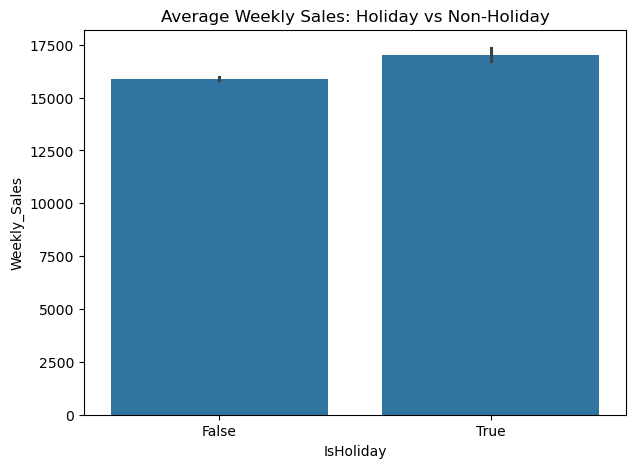

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- Visualization 1: Average Weekly Sales on Holidays vs Non-Holidays ---
plt.figure(figsize=(7, 5))
sns.barplot(x='IsHoliday', y='Weekly_Sales', data=df)
plt.title('Average Weekly Sales: Holiday vs Non-Holiday')
plt.show()

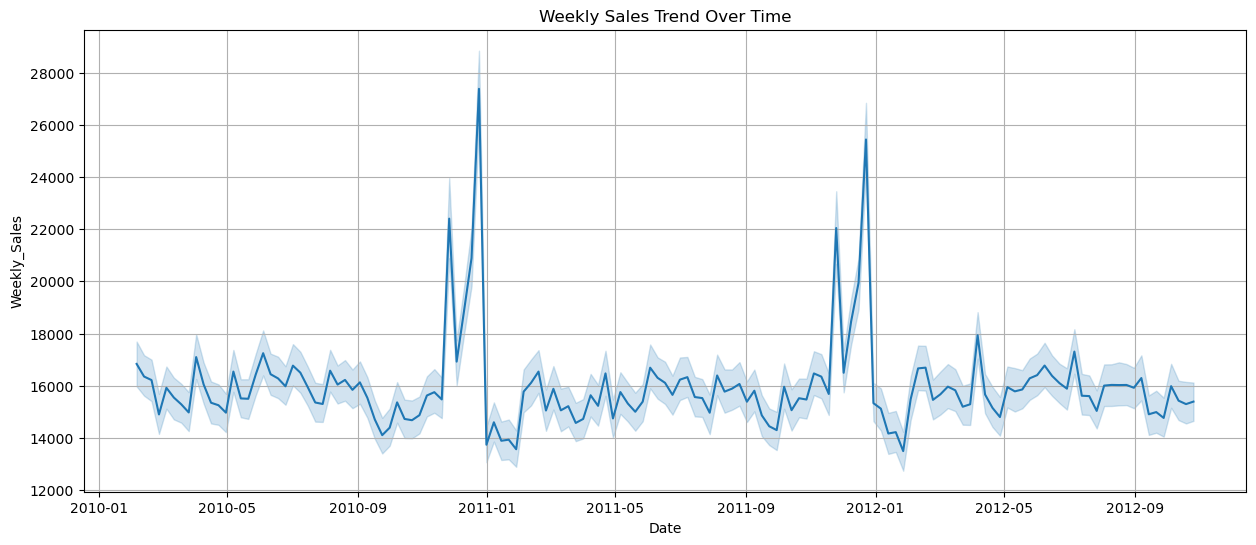

In [9]:
# --- Visualization 2: Weekly Sales Trend Across the Year ---
plt.figure(figsize=(15, 6))
sns.lineplot(x='Date', y='Weekly_Sales', data=df)
plt.title('Weekly Sales Trend Over Time')
plt.grid()
plt.show()

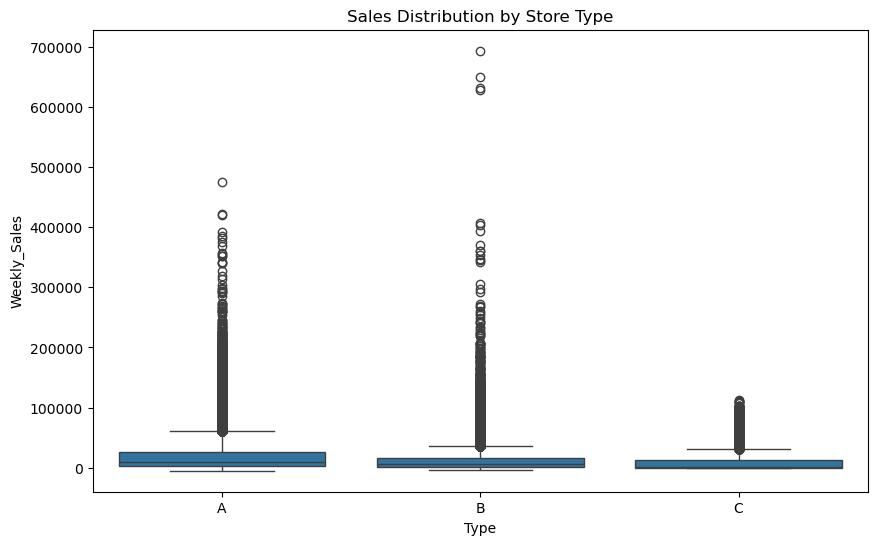

In [10]:
# --- Visualization 3: Weekly Sales by Store Type (A, B, C) ---
plt.figure(figsize=(10, 6))
sns.boxplot(x='Type', y='Weekly_Sales', data=df)
plt.title('Sales Distribution by Store Type')
plt.show()

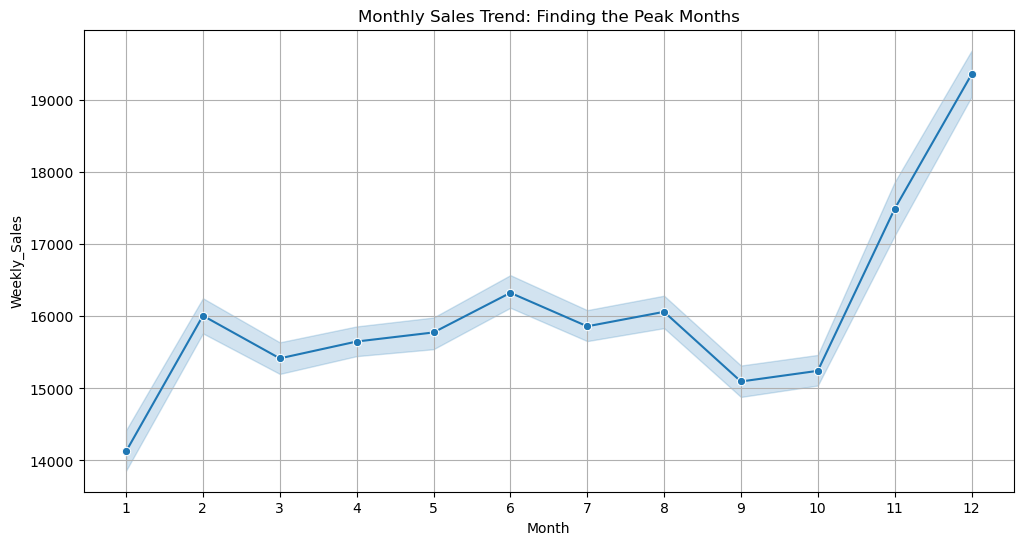

In [11]:
# --- Visualization 2: Monthly Sales Patterns ---
plt.figure(figsize=(12, 6))
# Month-wise average sales line plot
sns.lineplot(x='Month', y='Weekly_Sales', data=df, marker='o')
plt.title('Monthly Sales Trend: Finding the Peak Months')
plt.xticks(range(1, 13)) # 1 to 12 months
plt.grid(True)
plt.show()

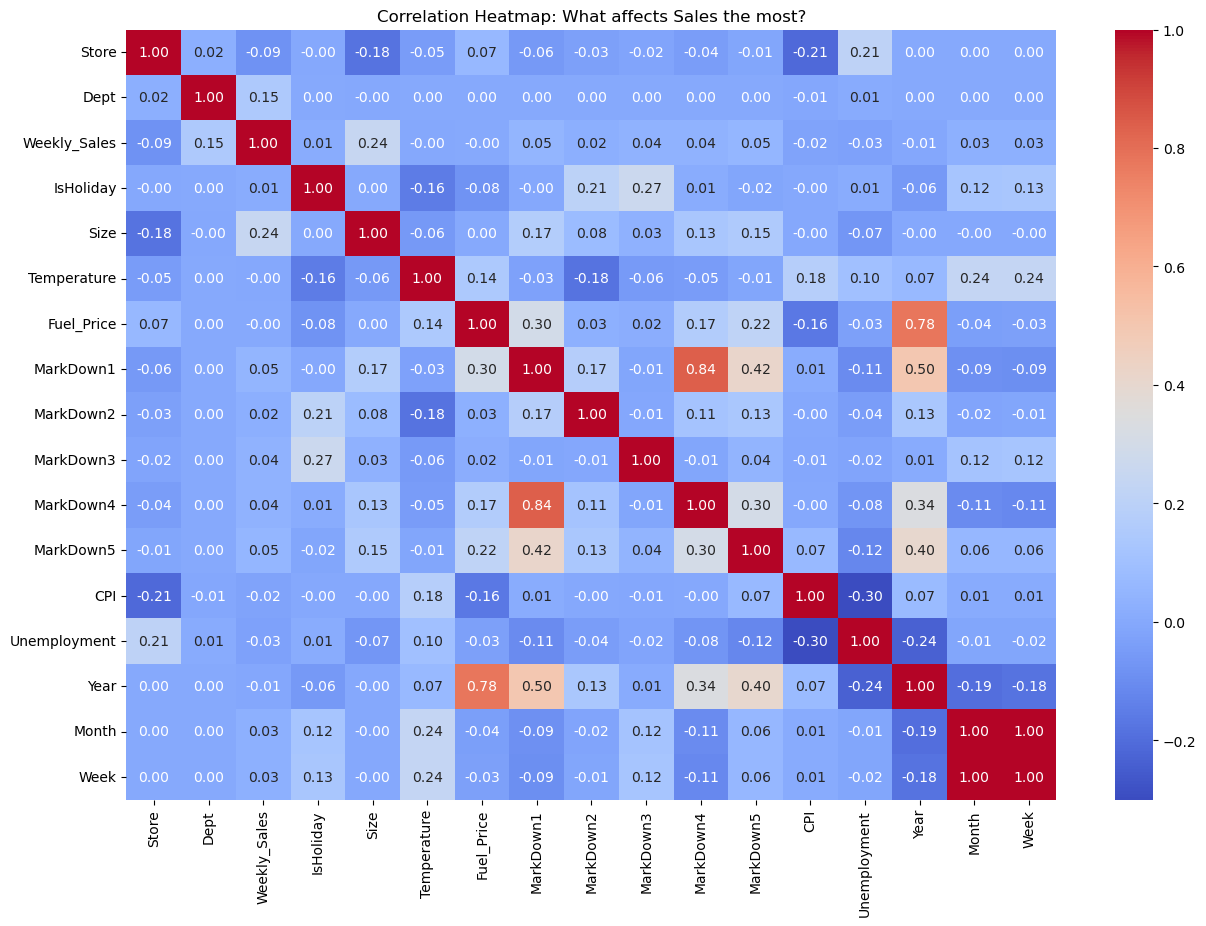

In [12]:
# --- Visualization 3: Correlation Heatmap ---
plt.figure(figsize=(15, 10))
# We are only calculating the correlation of numerical columns.
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap: What affects Sales the most?')
plt.show()

In [14]:
# --- STEP 6: Label Encoding for Categorical Features ---
# The models don't understand text, so we will convert the type and values ​​into numbers.

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Convert type (a, b, c) to (0, 1, 2).
df['Type'] = le.fit_transform(df['Type'])

# Convert boolean values ​​(true, false) to (1, 0).
df['IsHoliday'] = le.fit_transform(df['IsHoliday'])

print("Encoding complete  All the data is now in numbers.")

Encoding complete  All the data is now in numbers.


In [15]:
from sklearn.model_selection import train_test_split

# Separate the features (X) and the target (y).
X = df[['Store', 'Dept', 'Size', 'Type', 'IsHoliday', 'Month', 'Week', 'Year']]
y = df['Weekly_Sales']

# 80% of the data is used for training and 20% for testing.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training rows: {X_train.shape[0]}, Testing rows: {X_test.shape[0]}")

Training rows: 337256, Testing rows: 84314


In [16]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# --- STEP 7: Training the Random Forest Model --
# We create a forest with 100 trees
# 'n_jobs=-1' means your computer will work at full capacity.
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

print("Model training is starting... This may take 1-2 minutes.")
rf_model.fit(X_train, y_train)
print("Training Complete!")

# Check the prediction
y_pred = rf_model.predict(X_test)
print(f"Model  Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_pred)}")

Model training is starting... This may take 1-2 minutes.
Training Complete!
Model  Mean Absolute Error (MAE): 1339.9257591218538


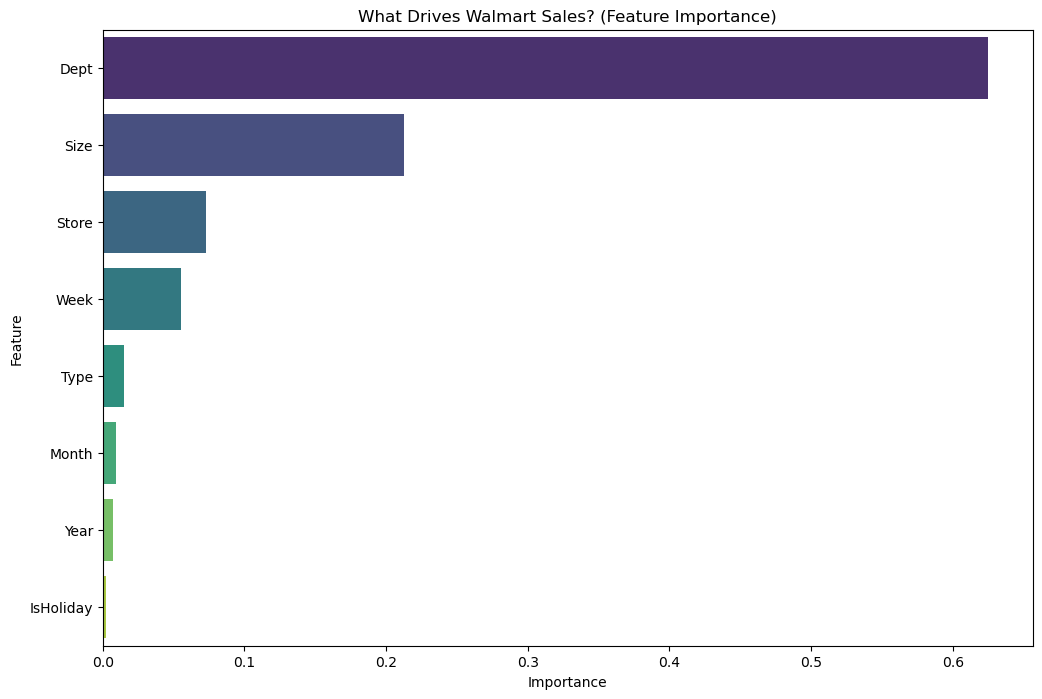

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extracting importance values from the model
importances = rf_model.feature_importances_
features = X.columns

# 2. Create data frames to make plotting easier.
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 3. Visualization
plt.figure(figsize=(12, 8))
# sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, hue='Feature', palette='viridis', legend=False)
plt.title('What Drives Walmart Sales? (Feature Importance)')
plt.show()

In [18]:
import joblib

# Model save 
joblib.dump(rf_model, 'walmart_sales_rf_model.pkl')

print("Model saved successfully as 'walmart_sales_rf_model.pkl'!")

Model saved successfully as 'walmart_sales_rf_model.pkl'!
